# Experiment Analysis Notebook

This notebook **loads metrics dynamically** from each experiment's `metrics.json` (no hardcoded results).

It produces:
1. Summary tables
2. Local vs Federated vs Centralized comparison charts
3. Neural Network learning curves

Run all cells after experiments have written their `metrics.json` files.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# experiments/ is the parent of analysis/
EXPERIMENTS_DIR = Path('..').resolve()
FIGURES_DIR = EXPERIMENTS_DIR.parent / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

print('Experiments dir:', EXPERIMENTS_DIR)
print('Figures dir:', FIGURES_DIR)

Experiments dir: C:\Users\aadel\Desktop\University of London\Project\privacy-preserving-supply-chain-fl\experiments
Figures dir: C:\Users\aadel\Desktop\University of London\Project\privacy-preserving-supply-chain-fl\figures


## 1. Load all metrics.json files

In [2]:
def load_metrics(experiments_dir: Path):
    records = []
    for path in sorted(experiments_dir.glob('*/metrics*.json')):
        with open(path, encoding='utf-8') as f:
            data = json.load(f)
        data['_path'] = str(path)
        data['_folder'] = path.parent.name
        records.append(data)
    return records

metrics_list = load_metrics(EXPERIMENTS_DIR)
print(f'Loaded {len(metrics_list)} metrics file(s):')
for m in metrics_list:
    print(f"  - {m.get('experiment_id', m['_folder'])}  source={m.get('source', '?')}")

Loaded 8 metrics file(s):
  - 01_logistic_regression_geographic  source=flower_history
  - 02_logistic_regression_strong_non_iid  source=flower_history
  - 03_logistic_regression_increased_epochs  source=flower_history
  - 04_neural_network_3rounds  source=flower_history
  - 05_neural_network_local_baselines  source=local_baseline_nn
  - 05_neural_network_local_baselines  source=local_baseline_nn
  - 06_centralized_neural_network  source=centralized_baseline_nn
  - 07_neural_network_5rounds  source=flower_history


## 2. Build a flat results table

In [3]:
rows = []
for m in metrics_list:
    exp_id = m.get('experiment_id', m['_folder'])
    results = m.get('results', {})

    if 'federated' in results:
        fed = results['federated']
        rows.append({
            'experiment': exp_id,
            'setting': 'federated',
            'accuracy': fed.get('accuracy'),
            'f1_score': fed.get('f1_score'),
            'loss': fed.get('loss'),
            'source': m.get('source'),
        })

    if 'local' in results:
        loc = results['local']
        rows.append({
            'experiment': exp_id,
            'setting': f"local_{m.get('client_id', 'client')}",
            'accuracy': loc.get('accuracy'),
            'f1_score': loc.get('f1_score'),
            'loss': None,
            'source': m.get('source'),
        })

    if 'centralized' in results:
        cen = results['centralized']
        rows.append({
            'experiment': exp_id,
            'setting': 'centralized',
            'accuracy': cen.get('accuracy'),
            'f1_score': cen.get('f1_score'),
            'loss': None,
            'source': m.get('source'),
        })

    # Nested local baselines (if stored in one file)
    for key in ('local_client_1_express', 'local_client_2_standard',
                'local_client_1_europe', 'local_client_2_latam'):
        if key in results:
            loc = results[key]
            rows.append({
                'experiment': exp_id,
                'setting': key,
                'accuracy': loc.get('accuracy'),
                'f1_score': loc.get('f1_score'),
                'loss': None,
                'source': m.get('source'),
            })

df = pd.DataFrame(rows)
df

,experiment,setting,accuracy,f1_score,loss,source
0,01_logistic_regression_geographic,federated,0.550755,0.696967,0.449245,flower_history
1,02_logistic_regression_strong_non_iid,federated,0.550755,0.696967,0.449245,flower_history
2,03_logistic_regression_increased_epochs,federated,0.550755,0.696967,0.449245,flower_history
3,04_neural_network_3rounds,federated,0.687993,0.611807,0.312007,flower_history
4,05_neural_network_local_baselines,local_client_1_express,0.846359,0.905934,NaN,local_baseline_nn
5,05_neural_network_local_baselines,local_client_2_standard,0.655102,0.519910,NaN,local_baseline_nn
6,06_centralized_neural_network,centralized,0.697679,0.666279,NaN,centralized_baseline_nn
7,07_neural_network_5rounds,federated,0.695056,0.601149,0.304944,flower_history


## 3. Main comparison chart (Accuracy & F1)

Builds the chart from whatever federated / local / centralized rows are available in the loaded metrics.

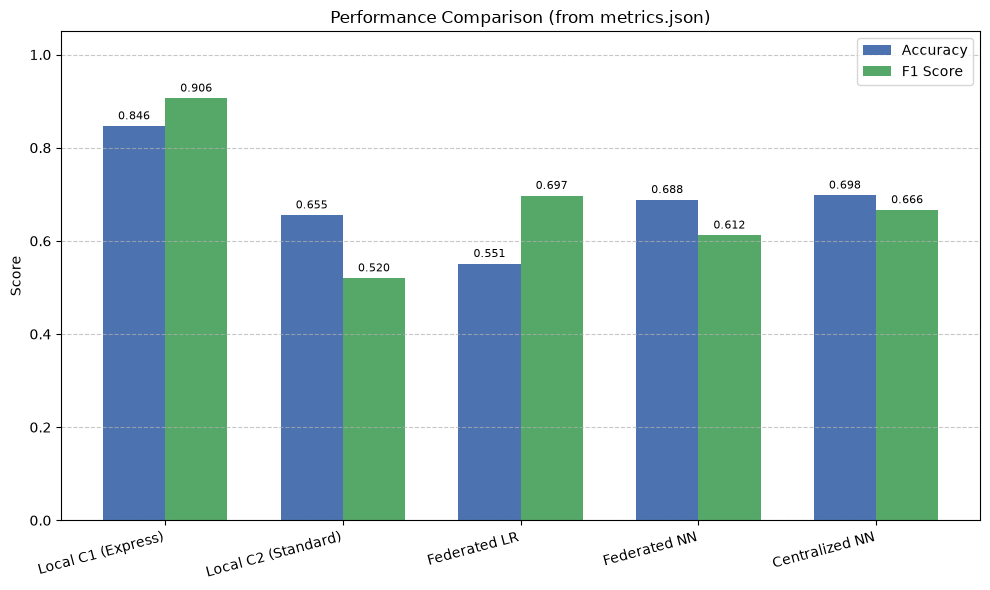

Saved: C:\Users\aadel\Desktop\University of London\Project\privacy-preserving-supply-chain-fl\figures\comparison_from_metrics.png


In [4]:
# Prefer these labels when present in the data
preferred = [
    ('05_neural_network_local_baselines', 'local_client_1_express', 'Local C1 (Express)'),
    ('05_neural_network_local_baselines', 'local_client_2_standard', 'Local C2 (Standard)'),
    ('02_logistic_regression_strong_non_iid', 'federated', 'Federated LR'),
    ('04_neural_network_3rounds', 'federated', 'Federated NN'),
    ('06_centralized_neural_network', 'centralized', 'Centralized NN'),
]

# Also accept client_id-based local rows
alt_local = {
    'local_client_1_express': 'Local C1 (Express)',
    'local_client_2_standard': 'Local C2 (Standard)',
    'local_client_1': 'Local C1 (Express)',
    'local_client_2': 'Local C2 (Standard)',
}

labels, accs, f1s = [], [], []

for exp, setting, label in preferred:
    subset = df[(df['experiment'] == exp) & (df['setting'] == setting)]
    if subset.empty:
        # try matching by setting only for local files written per client
        subset = df[df['setting'] == setting]
    if subset.empty and setting.startswith('local'):
        subset = df[df['setting'].str.contains('client_1|express', case=False, na=False)] if '1' in setting or 'express' in setting else df[df['setting'].str.contains('client_2|standard', case=False, na=False)]
        subset = subset[subset['experiment'].str.contains('05|local', case=False, na=False)]
    if not subset.empty:
        row = subset.iloc[-1]
        if pd.notna(row['accuracy']):
            labels.append(label)
            accs.append(row['accuracy'])
            f1s.append(row['f1_score'] if pd.notna(row['f1_score']) else 0.0)

# Fallback: plot all federated + centralized rows if preferred set is incomplete
if len(labels) < 2:
    labels, accs, f1s = [], [], []
    for _, row in df.dropna(subset=['accuracy']).iterrows():
        labels.append(f"{row['experiment'][:20]}|{row['setting']}")
        accs.append(row['accuracy'])
        f1s.append(row['f1_score'] if pd.notna(row['f1_score']) else 0.0)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='#4C72B0')
b2 = ax.bar(x + width/2, f1s, width, label='F1 Score', color='#55A868')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison (from metrics.json)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
out = FIGURES_DIR / 'comparison_from_metrics.png'
plt.savefig(out, dpi=300)
plt.show()
print('Saved:', out)

## 4. Learning curves (from per-round federated metrics)

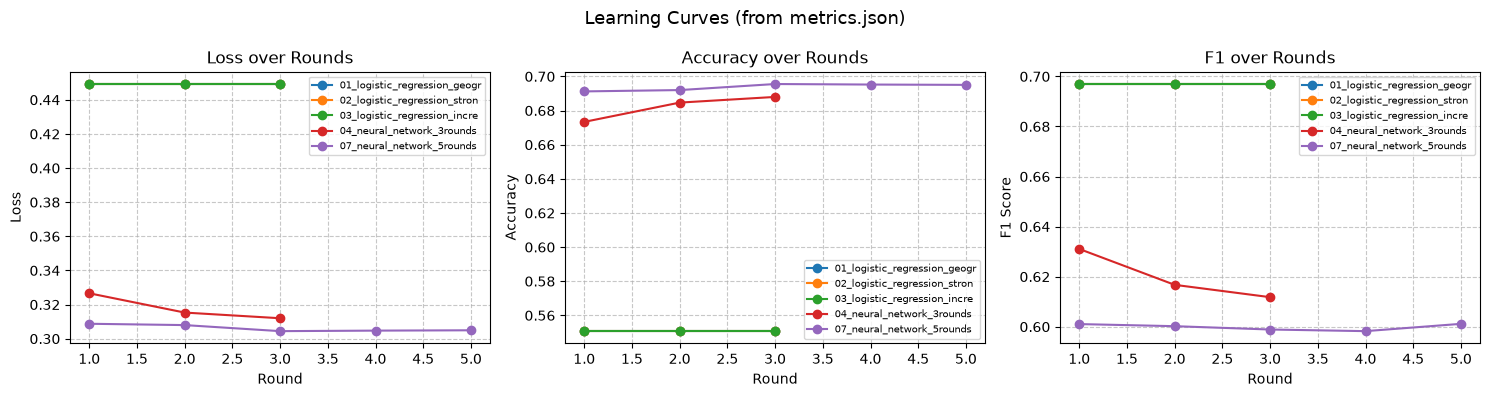

Saved: C:\Users\aadel\Desktop\University of London\Project\privacy-preserving-supply-chain-fl\figures\learning_curves_from_metrics.png


In [5]:
def extract_per_round(m):
    fed = m.get('results', {}).get('federated', {})
    pr = fed.get('per_round', {})
    if not pr:
        return None
    return {
        'id': m.get('experiment_id', m['_folder']),
        'accuracy': pr.get('accuracy', []),
        'f1_score': pr.get('f1_score', []),
        'loss': pr.get('loss', []),
    }

curves = [extract_per_round(m) for m in metrics_list]
curves = [c for c in curves if c and (c['accuracy'] or c['loss'])]

if not curves:
    print('No per-round metrics found. Re-run a federated experiment to generate them.')
else:
    n = len(curves)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for c in curves:
        rounds_acc = list(range(1, len(c['accuracy']) + 1))
        rounds_f1 = list(range(1, len(c['f1_score']) + 1))
        rounds_loss = list(range(1, len(c['loss']) + 1))
        if c['loss']:
            axes[0].plot(rounds_loss, c['loss'], marker='o', label=c['id'][:28])
        if c['accuracy']:
            axes[1].plot(rounds_acc, c['accuracy'], marker='o', label=c['id'][:28])
        if c['f1_score']:
            axes[2].plot(rounds_f1, c['f1_score'], marker='o', label=c['id'][:28])

    axes[0].set_title('Loss over Rounds')
    axes[0].set_xlabel('Round')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].set_title('Accuracy over Rounds')
    axes[1].set_xlabel('Round')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    axes[2].set_title('F1 over Rounds')
    axes[2].set_xlabel('Round')
    axes[2].set_ylabel('F1 Score')
    axes[2].grid(True, linestyle='--', alpha=0.7)

    for ax in axes:
        ax.legend(fontsize=7)

    plt.suptitle('Learning Curves (from metrics.json)', fontsize=13)
    plt.tight_layout()
    out = FIGURES_DIR / 'learning_curves_from_metrics.png'
    plt.savefig(out, dpi=300)
    plt.show()
    print('Saved:', out)

## 5. Export summary CSV for the report

In [6]:
summary_path = FIGURES_DIR / 'metrics_summary.csv'
df.to_csv(summary_path, index=False)
print('Saved:', summary_path)
df

Saved: C:\Users\aadel\Desktop\University of London\Project\privacy-preserving-supply-chain-fl\figures\metrics_summary.csv


,experiment,setting,accuracy,f1_score,loss,source
0,01_logistic_regression_geographic,federated,0.550755,0.696967,0.449245,flower_history
1,02_logistic_regression_strong_non_iid,federated,0.550755,0.696967,0.449245,flower_history
2,03_logistic_regression_increased_epochs,federated,0.550755,0.696967,0.449245,flower_history
3,04_neural_network_3rounds,federated,0.687993,0.611807,0.312007,flower_history
4,05_neural_network_local_baselines,local_client_1_express,0.846359,0.905934,NaN,local_baseline_nn
5,05_neural_network_local_baselines,local_client_2_standard,0.655102,0.519910,NaN,local_baseline_nn
6,06_centralized_neural_network,centralized,0.697679,0.666279,NaN,centralized_baseline_nn
7,07_neural_network_5rounds,federated,0.695056,0.601149,0.304944,flower_history
